In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# -- What symbol and timeframe to analyse ---------
DATA_SOURCE      = "binance"
BINANCE_SYMBOL   = "BTCUSDT"
BINANCE_INTERVAL = "1h"

# -- Trend detection sensitivity ----------------
# These must match notebook 08 exactly so the analysis is consistent.
# USE_PARENT_RELATIVE_FILTER: reject impulses smaller than X% of the full window
USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO   = 0.15   # 15% of window range minimum

# USE_MOMENTUM_FILTER: reject impulses smaller than X% of the previous impulse
USE_MOMENTUM_FILTER  = True
MIN_MOMENTUM_RATIO   = 0.5          # new impulse must be at least 50% as large

# USE_DOMINANCE_FILTER: reject impulses smaller than X times the preceding retracement
USE_DOMINANCE_FILTER  = True
MIN_DOMINANCE_RATIO   = 1.5         # impulse must be 50% larger than the retracement

FILTER_CONFIG = {
    "use_parent_relative_filter": USE_PARENT_RELATIVE_FILTER,
    "min_impulse_parent_ratio":   MIN_IMPULSE_PARENT_RATIO,
    "use_momentum_filter":        USE_MOMENTUM_FILTER,
    "min_momentum_ratio":         MIN_MOMENTUM_RATIO,
    "use_dominance_filter":       USE_DOMINANCE_FILTER,
    "min_dominance_ratio":        MIN_DOMINANCE_RATIO,
}

# -- Structural walker depth -------------------
# MAX_DEPTH controls how many levels deep the recursive retracement analysis goes.
# 1 = only analyse the top level of the current retracement
# 2 = analyse the response move inside the retracement as well
# 3-4 = deeper nesting — useful when retracement is complex and has multiple layers
# Start with 3. Increase if the retracement has been running for many days.
MAX_DEPTH = 3

# LOOKBACK_DAYS: how many days of history to fetch.
# 100 days captures the full November 2025 trend on 1H.
# Increase if the global trend started earlier than 100 days ago.
LOOKBACK_DAYS = 100


In [2]:
from datetime import datetime, timedelta, timezone
from src.adapters.binance_data import fetch_binance_ohlc_sync
from src.core.trend_id import identify_trend, compute_internal_structure
from src.core.structure_levels import compute_all_structure_levels, compute_internal_structure_levels
from src.core.retracement_depth import annotate_legs_with_depth
from src.core.leg_metrics import annotate_legs_with_metrics
from src.core.structural_walker import walk_structure

# Fetch candles from Binance
start_time = datetime.now(timezone.utc) - timedelta(days=LOOKBACK_DAYS)
candles = fetch_binance_ohlc_sync(BINANCE_SYMBOL, BINANCE_INTERVAL, start_time=start_time)

# Run the full pipeline
result = identify_trend(candles, **FILTER_CONFIG)
compute_internal_structure(candles, result["legs"], **FILTER_CONFIG)
compute_internal_structure_levels(candles, result["legs"])
annotate_legs_with_depth(result["legs"])
annotate_legs_with_metrics(result["legs"], candles, BINANCE_INTERVAL, is_synthetic=False)

# Walk the recursive structure
state_report = walk_structure(candles, result, FILTER_CONFIG, max_depth=MAX_DEPTH)

# Compute the 'waiting_for' message
confirmed_legs = sum(1 for leg in result["legs"] if leg.get("confirmed") is True)
last_ts = candles[-1].timestamp.strftime('%Y-%m-%d %H:%M:%S') if candles else 'N/A'
date_range_start = candles[0].timestamp.strftime('%Y-%m-%d') if candles else 'N/A'
date_range_end = candles[-1].timestamp.strftime('%Y-%m-%d') if candles else 'N/A'

confirmed_impulses_count = sum(1 for l in result["legs"] if l.get("confirmed") and l.get("type") == "impulse")
confirmed_retracements_count = sum(1 for l in result["legs"] if l.get("confirmed") and l.get("type") == "retracement")

print("── Data loaded ───────────────────────────────────────────────────────────────")
print(f"Symbol: {BINANCE_SYMBOL}  |  Interval: {BINANCE_INTERVAL}  |  Candles: {len(candles)}")
print(f"Date range: {date_range_start} → {date_range_end}")
print()
print("── Global trend ──────────────────────────────────────────────────────────────")
print(f"Direction: {result['trend']}")
print(f"Confirmed legs: {confirmed_legs}  ({confirmed_impulses_count} impulses, {confirmed_retracements_count} retracements)")
print(f"Current phase: {result['current_phase']}")
print()
print("── Retracement analysis ──────────────────────────────────────────────────────")
print(f"Walkable: {state_report['walkable']}")
print(f"Depth reached: {state_report['max_depth_reached']}")
print(f"Mitigations found: {state_report['total_mitigation_count']}  ← number of false breaks detected inside the retracement")
print(f"Waiting for: {state_report['waiting_for']}")


── Data loaded ───────────────────────────────────────────────────────────────
Symbol: BTCUSDT  |  Interval: 1h  |  Candles: 2400
Date range: 2025-12-11 → 2026-03-21

── Global trend ──────────────────────────────────────────────────────────────
Direction: down
Confirmed legs: 2  (1 impulses, 1 retracements)
Current phase: retracement

── Retracement analysis ──────────────────────────────────────────────────────
Walkable: True
Depth reached: 3
Mitigations found: 2  ← number of false breaks detected inside the retracement
Waiting for: Maximum analysis depth reached — monitor active CHoCH zone


BOS | price=60000.00 | start=1357 (2026-02-06 00:00:00+00:00) | end=2399 (2026-03-21 10:00:00+00:00) | broken=True

Global CHoCH zone: not yet computable (fewer than 2 confirmed impulses)


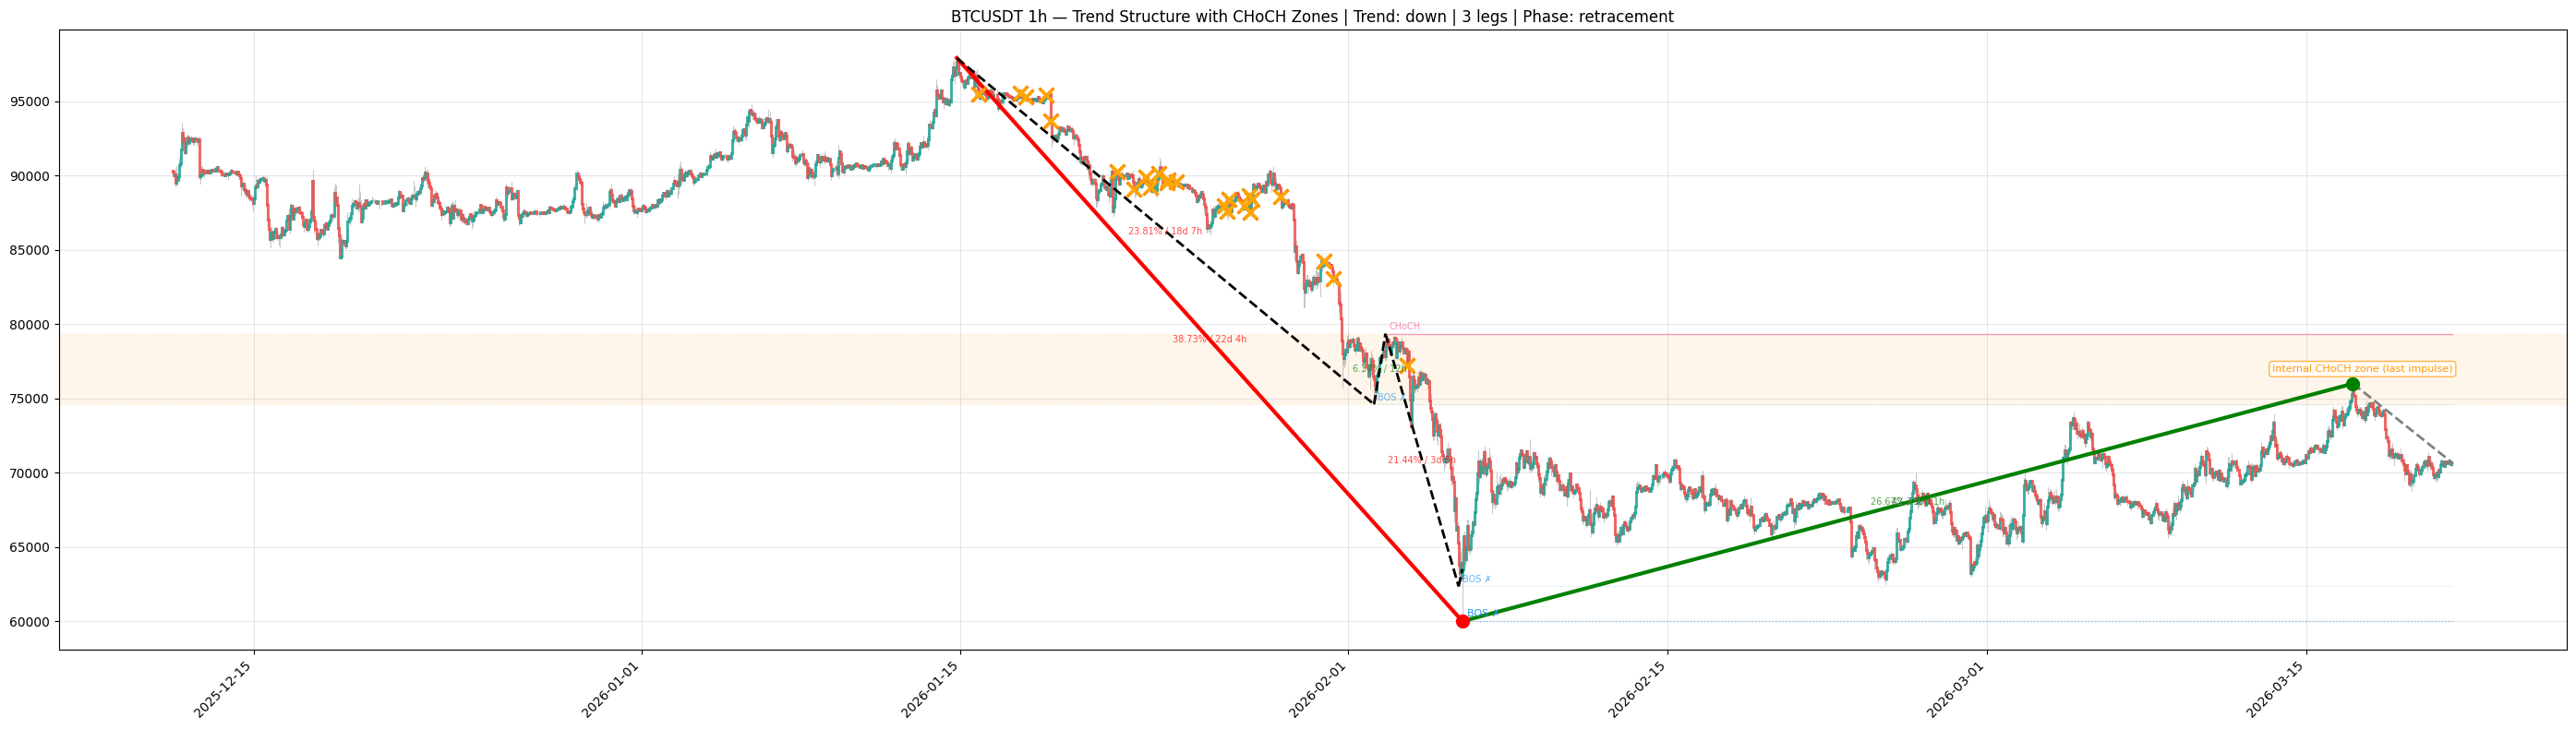


=== What you are looking at ===
- Red/green lines: global impulses and retracements
- Black dashed lines: internal structure inside the most recent impulse only
- Pink shaded band: the global CHoCH zone — if price reaches here, the global trend may be ending
- Orange shaded band: the internal CHoCH zone — the first warning level inside the last impulse
- Blue dashed lines: BOS levels (Break of Structure) — prior structural highs/lows


In [3]:
import matplotlib.pyplot as plt
from src.visualization.trend_chart import draw_trend_chart
from src.core.choch_zone import get_active_choch_zone

# Get the active CHoCH zones (both global and internal)
global_choch = get_active_choch_zone(result["legs"], result["trend"], candles)

# Get internal CHoCH zone for the most recent confirmed impulse
confirmed_impulses = [l for l in result["legs"] if l.get("type") == "impulse" and l.get("confirmed")]
internal_choch = None
if confirmed_impulses:
    last_impulse = confirmed_impulses[-1]
    if last_impulse.get("internal_structure"):
        internal_legs = last_impulse["internal_structure"]["legs"]
        internal_trend = last_impulse["internal_structure"]["trend"]
        start_idx = int(last_impulse["start_index"])
        end_idx = int(last_impulse["end_index"])
        internal_candles = candles[start_idx:end_idx+1]
        internal_choch_result = get_active_choch_zone(internal_legs, internal_trend, internal_candles)
        internal_choch = internal_choch_result["choch_zone"] if internal_choch_result else None

# Draw the main chart
fig, ax = plt.subplots(figsize=(28, 8))
ax = draw_trend_chart(
    candles,
    result,
    f"{BINANCE_SYMBOL} {BINANCE_INTERVAL} — Trend Structure with CHoCH Zones",
    use_datetime_axis=True,
    ax=ax
)

# Add global CHoCH zone
if global_choch and global_choch.get("choch_zone"):
    zone = global_choch["choch_zone"]
    ax.axhspan(
        zone["lower_boundary"],
        zone["upper_boundary"],
        alpha=0.08,
        color="#E91E63",
        label="Global CHoCH zone"
    )
    # Label at the right edge
    mid = (zone["lower_boundary"] + zone["upper_boundary"]) / 2
    ax.text(
        candles[-1].timestamp,
        mid,
        "Global CHoCH zone",
        color="#E91E63",
        fontsize=8,
        ha="right",
        va="center",
        bbox=dict(facecolor="white", edgecolor="#E91E63", alpha=0.7, boxstyle="round,pad=0.3")
    )
else:
    print("\nGlobal CHoCH zone: not yet computable (fewer than 2 confirmed impulses)")

# Add internal CHoCH zone
if internal_choch:
    ax.axhspan(
        internal_choch["lower_boundary"],
        internal_choch["upper_boundary"],
        alpha=0.08,
        color="#FF9800",
        linestyle="--",
        label="Internal CHoCH zone (last impulse)"
    )
    # Label at the right edge
    mid = (internal_choch["lower_boundary"] + internal_choch["upper_boundary"]) / 2
    ax.text(
        candles[-1].timestamp,
        mid,
        "Internal CHoCH zone (last impulse)",
        color="#FF9800",
        fontsize=8,
        ha="right",
        va="center",
        bbox=dict(facecolor="white", edgecolor="#FF9800", alpha=0.7, boxstyle="round,pad=0.3")
    )
else:
    print("\nInternal CHoCH zone: not yet computable (impulse needs 2+ internal impulses)")

plt.tight_layout()
plt.show()

print("\n=== What you are looking at ===")
print("- Red/green lines: global impulses and retracements")
print("- Black dashed lines: internal structure inside the most recent impulse only")
print("- Pink shaded band: the global CHoCH zone — if price reaches here, the global trend may be ending")
print("- Orange shaded band: the internal CHoCH zone — the first warning level inside the last impulse")
print("- Blue dashed lines: BOS levels (Break of Structure) — prior structural highs/lows")

=== Retracement Deep-Dive: All Structural Layers ===

This chart shows the full retracement from its start to now.
Every layer of internal structure is drawn on the same canvas.

How to read this chart:
- OHLC bars: the raw price action of the retracement in grey
- Each color represents one depth layer of structure:
    Depth 1 (blue):   the first move up within the retracement
    Depth 2 (green):  the move that started from the CHoCH of depth 1
    Depth 3 (purple): the move that started from the CHoCH of depth 2
    Depth 4 (orange): the move that started from the CHoCH of depth 3
- Solid lines: the zigzag legs of each layer (confirmed legs only)
- Dotted lines: internal structure within each confirmed impulse leg
- Shaded band: the CHoCH zone of each layer
- Horizontal line: the BOS (structural level) of each layer
- If a BOS line is labelled "mitigated": the move from the CHoCH
  failed to break that structure and returned inside


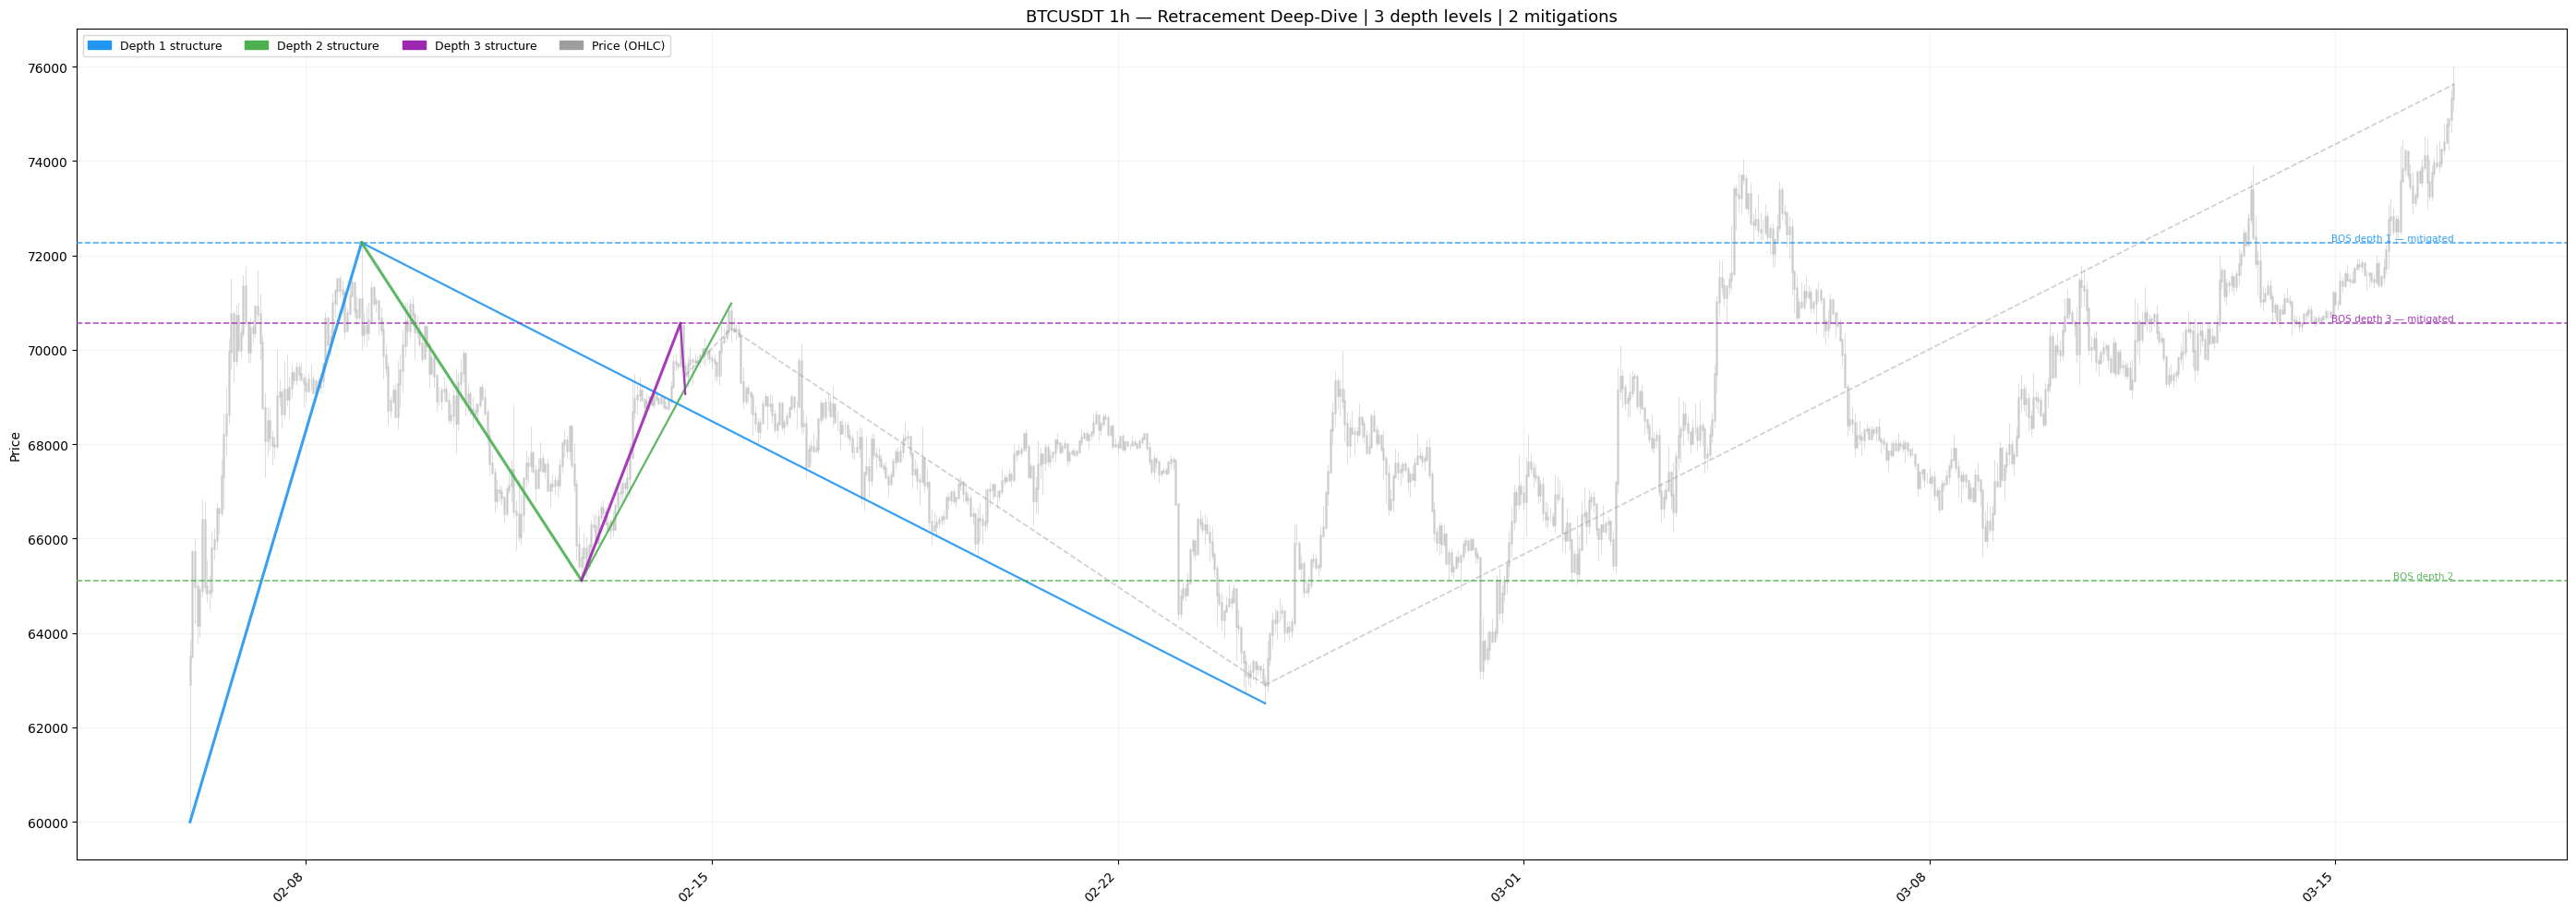

In [4]:
print("=== Retracement Deep-Dive: All Structural Layers ===")
print()
print("This chart shows the full retracement from its start to now.")
print("Every layer of internal structure is drawn on the same canvas.")
print()
print("How to read this chart:")
print("- OHLC bars: the raw price action of the retracement in grey")
print("- Each color represents one depth layer of structure:")
print("    Depth 1 (blue):   the first move up within the retracement")
print("    Depth 2 (green):  the move that started from the CHoCH of depth 1")
print("    Depth 3 (purple): the move that started from the CHoCH of depth 2")
print("    Depth 4 (orange): the move that started from the CHoCH of depth 3")
print("- Solid lines: the zigzag legs of each layer (confirmed legs only)")
print("- Dotted lines: internal structure within each confirmed impulse leg")
print("- Shaded band: the CHoCH zone of each layer")
print("- Horizontal line: the BOS (structural level) of each layer")
print("- If a BOS line is labelled \"mitigated\": the move from the CHoCH")
print("  failed to break that structure and returned inside")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

# Layer color scheme — one color per depth level
LAYER_COLORS = {
    1: "#2196F3",   # blue
    2: "#4CAF50",   # green
    3: "#9C27B0",   # purple
    4: "#FF9800",   # orange
}

levels = state_report.get("levels", [])

if not state_report.get("walkable") or not levels:
    print(f"Retracement not walkable: {state_report.get('reason')}")
else:
    # Find the retracement canvas bounds from level 1
    canvas_start = levels[0]["layer_start_index"]
    canvas_end = levels[0]["layer_end_index"]
    if canvas_end is None:
        canvas_end = len(candles) - 1
    canvas_candles = candles[canvas_start:canvas_end + 1]

    fig, ax = plt.subplots(figsize=(28, 10))

    # Draw OHLC bars for the retracement slice — grey wicks, grey bodies
    for c in canvas_candles:
        ts = c.timestamp
        ax.plot([ts, ts], [c.low, c.high],
                color='#9E9E9E', linewidth=0.5, alpha=0.5, zorder=1)
        ax.plot([ts, ts], [c.open, c.close],
                color='#BDBDBD', linewidth=1.8, alpha=0.6, zorder=2)

    # Draw each depth layer
    for level in levels:
        depth = level["depth"]
        color = LAYER_COLORS.get(depth, "#607D8B")
        rmt = level.get("rmt_result")
        layer_start = level["layer_start_index"]
        layer_end = level["layer_end_index"]
        if layer_end is None:
            layer_end = len(candles) - 1
        analysis = level.get("analysis") or {}

        if rmt is None:
            continue

        # Draw zigzag legs for this layer
        for leg in rmt.get("legs", []):
            if not leg.get("confirmed"):
                # Unconfirmed open leg — grey dotted
                ls = leg.get("start_index")
                if ls is None:
                    continue
                gs = layer_start + int(ls)
                ge = layer_end
                gs = max(canvas_start, min(gs, canvas_end))
                ge = max(canvas_start, min(ge, canvas_end))
                ax.plot(
                    [candles[gs].timestamp, candles[ge].timestamp],
                    [candles[gs].close, candles[ge].close],
                    color='#9E9E9E', linewidth=1.2,
                    linestyle='--', alpha=0.5, zorder=3
                )
                continue

            ls = leg.get("start_index")
            le = leg.get("end_index")
            if ls is None or le is None:
                continue
            gs = layer_start + int(ls)
            ge = layer_start + int(le)
            gs = max(canvas_start, min(gs, canvas_end))
            ge = max(canvas_start, min(ge, canvas_end))
            if gs >= ge:
                continue

            # Solid zigzag line for this leg
            ax.plot(
                [candles[gs].timestamp, candles[ge].timestamp],
                [leg["start_price"], leg["end_price"]],
                color=color,
                linewidth=2.2 if leg["type"] == "impulse" else 1.6,
                linestyle='-',
                alpha=0.9,
                zorder=4 + depth,
                label=f"Depth {depth} {leg['type']}" if leg == rmt['legs'][0] else None
            )

            # Internal structure — dotted lines, same color, thinner
            internal = leg.get("internal_structure")
            if internal and leg["type"] == "impulse":
                for ileg in internal.get("legs", []):
                    if not ileg.get("confirmed"):
                        continue
                    ils = ileg.get("start_index")
                    ile = ileg.get("end_index")
                    if ils is None or ile is None:
                        continue
                    # Internal indices are relative to the leg slice
                    igs = gs + int(ils)
                    ige = gs + int(ile)
                    igs = max(canvas_start, min(igs, canvas_end))
                    ige = max(canvas_start, min(ige, canvas_end))
                    if igs >= ige:
                        continue
                    ax.plot(
                        [candles[igs].timestamp, candles[ige].timestamp],
                        [ileg["start_price"], ileg["end_price"]],
                        color=color,
                        linewidth=0.8,
                        linestyle=':',
                        alpha=0.6,
                        zorder=3
                    )

        # Draw BOS (structural level) for this layer
        structural_level = analysis.get("structural_level")
        if structural_level:
            bos_price = structural_level["price"]
            is_mitigated = analysis.get("most_recent_attempt_result") == "false_break"
            ax.axhline(
                y=bos_price,
                color=color,
                linewidth=1.2,
                linestyle='--',
                alpha=0.8,
                zorder=5
            )
            label_text = f"BOS depth {depth}" + (" — mitigated" if is_mitigated else "")
            ax.text(
                candles[canvas_end].timestamp,
                bos_price,
                label_text,
                color=color,
                fontsize=7.5,
                ha='right',
                va='bottom',
                alpha=0.9
            )

        # Draw CHoCH zone for this layer
        rmt_choch = analysis.get("rmt_choch_zone")
        if rmt_choch:
            ax.axhspan(
                rmt_choch["lower_boundary"],
                rmt_choch["upper_boundary"],
                alpha=0.06,
                color=color,
                zorder=2
            )
            mid = (rmt_choch["lower_boundary"] + rmt_choch["upper_boundary"]) / 2
            ax.text(
                candles[canvas_start].timestamp,
                mid,
                f"CHoCH zone depth {depth}",
                color=color,
                fontsize=7,
                ha='left',
                va='center',
                alpha=0.8
            )

    # Legend — one entry per depth level present
    legend_patches = []
    for level in levels:
        d = level["depth"]
        c = LAYER_COLORS.get(d, "#607D8B")
        legend_patches.append(
            mpatches.Patch(color=c, label=f"Depth {d} structure")
        )
    legend_patches.append(
        mpatches.Patch(color='#9E9E9E', label='Price (OHLC)')
    )
    ax.legend(handles=legend_patches, loc='upper left', ncol=len(legend_patches), fontsize=9)

    # Axis formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(
        f"{BINANCE_SYMBOL} {BINANCE_INTERVAL} — Retracement Deep-Dive | "
        f"{len(levels)} depth levels | "
        f"{state_report['total_mitigation_count']} mitigations",
        fontsize=13
    )
    ax.set_ylabel('Price')
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

In [5]:
from pprint import pformat

last_ts = candles[-1].timestamp.strftime('%Y-%m-%d %H:%M:%S')

print('══════════════════════════════════════════════════════════════════════════════')
print(' WHAT THE ALGORITHM SEES RIGHT NOW')
print(f' {BINANCE_SYMBOL} {BINANCE_INTERVAL} — {last_ts}')
print('══════════════════════════════════════════════════════════════════════════════')
print()
print(f' Global trend: {result["trend"].upper()}')
if result["trend"] == "down":
    print(' The market has been making lower lows and lower highs.')
else:
    print(' The market has been making higher highs and higher lows.')
print()
print(f' Current phase: {result["current_phase"].upper()}')
if result["current_phase"] == "retracement":
    print(' The market is moving against the trend.')
    print(' This is where we look for entry opportunities.')
print()
print(' Internal structure layers detected:')
for level in state_report.get("levels", []):
    d = level["depth"]
    analysis = level.get("analysis") or {}
    sl = analysis.get("structural_level")
    choch = analysis.get("rmt_choch_zone")
    result_str = analysis.get("most_recent_attempt_result") or "no attempt yet"
    mitigations = analysis.get("mitigation_count", 0)
    bos_str = f"{sl['price']:.2f}" if sl else "not yet found"
    choch_str = (
        f"{choch['lower_boundary']:.2f} to {choch['upper_boundary']:.2f}"
        if choch else "not yet computable"
    )
    status = "MITIGATED" if result_str == "false_break" else (
        "REAL BREAK" if result_str == "real_break" else "ACTIVE — watching"
    )
    print(f'   Layer {d}: BOS at {bos_str} | CHoCH zone: {choch_str} | Status: {status} | Mitigations: {mitigations}')
print()
print(f' Total mitigations across all layers: {state_report["total_mitigation_count"]}')
print()
print(' What to watch for next:')
total_mit = state_report["total_mitigation_count"]
deepest = state_report.get("deepest_termination_reason", "")
if deepest == "max_depth_reached" and total_mit >= 2:
    print(' Multiple layers of buy-side structure have been cleared.')
    print(' Market is showing weakness in the retracement.')
    print(' Watch for the active CHoCH zone to be tested and hold.')
elif deepest == "waiting_for_response_move":
    print(' Waiting for the market to respond from the last CHoCH.')
    print(' No entry signal yet.')
else:
    print(f' {state_report.get("waiting_for", "Monitoring.")}')
print()
print(' Stars aligned (full entry signal): NO')
print(' Reason: RSI and EMA confluence checks not yet implemented (Phase 4)')
print('══════════════════════════════════════════════════════════════════════════════')
print()
print('# Raw state report (debug):')
print(pformat(state_report, width=120))

══════════════════════════════════════════════════════════════════════════════
 WHAT THE ALGORITHM SEES RIGHT NOW
 BTCUSDT 1h — 2026-03-21 10:00:00
══════════════════════════════════════════════════════════════════════════════

 Global trend: DOWN
 The market has been making lower lows and lower highs.

 Current phase: RETRACEMENT
 The market is moving against the trend.
 This is where we look for entry opportunities.

 Internal structure layers detected:
   Layer 1: BOS at 72271.41 | CHoCH zone: not yet computable | Status: MITIGATED | Mitigations: 1
   Layer 2: BOS at 65118.00 | CHoCH zone: not yet computable | Status: REAL BREAK | Mitigations: 0
   Layer 3: BOS at 70560.01 | CHoCH zone: not yet computable | Status: MITIGATED | Mitigations: 1

 Total mitigations across all layers: 2

 What to watch for next:
 Multiple layers of buy-side structure have been cleared.
 Market is showing weakness in the retracement.
 Watch for the active CHoCH zone to be tested and hold.

 Stars aligned 

In [6]:
from pprint import pformat

last_ts = candles[-1].timestamp.strftime('%Y-%m-%d %H:%M:%S') if candles else 'N/A'

print('══════════════════════════════════════════════════════════════════════════════')
print(' WHAT THE ALGORITHM SEES RIGHT NOW')
print(f' {BINANCE_SYMBOL} {BINANCE_INTERVAL} — {last_ts}')
print('══════════════════════════════════════════════════════════════════════════════')
print()

print(' Global trend: ' + result['trend'].upper())
if result['trend'] == 'down':
    print(' The market has been making lower lows and lower highs.')
else:
    print(' The market has been making higher highs and higher lows.')
print()

print(' Current phase: ' + result['current_phase'].upper())
if result['current_phase'] == 'retracement':
    print(' The market is currently moving against the trend.')
    print(' This is the phase where we look for entry opportunities.')
else:
    print(' The market is currently moving in the direction of the trend.')
print()

print(' Retracement analysis:')
if state_report.get('levels'):
    analysis = state_report['levels'][0].get('analysis')
    if analysis:
        mitigation_count = analysis.get('mitigation_count', 0)
        attempt_count = analysis.get('attempt_count', 0)
        print(f" - The retracement has made {attempt_count} upward attempt(s) that crossed the structural level.")
        if mitigation_count > 0:
            print(f" - {mitigation_count} mitigation(s) detected. More mitigations = weaker retracement = closer to trend resuming.")
print()

print(' What to watch for next:')
print(f" {state_report.get('waiting_for', 'Waiting for more structure')}")
print()

print(' CHoCH zones:')
if global_choch and global_choch.get('choch_zone'):
    gz = global_choch['choch_zone']
    print(f" - Global CHoCH: {gz['lower_boundary']:.2f} to {gz['upper_boundary']:.2f} — the level where the global trend would end")
if internal_choch:
    print(f" - Internal CHoCH: {internal_choch['lower_boundary']:.2f} to {internal_choch['upper_boundary']:.2f} — the first warning level inside the last impulse")
print()

print(' Stars aligned (full entry signal): NO')
print(' Reason: RSI divergence and EMA confluence checks not yet implemented (Phase 4)')
print('══════════════════════════════════════════════════════════════════════════════')
print()
print('Raw state report for debugging (full algorithm output):')
print(pformat(state_report, width=120, compact=False))

══════════════════════════════════════════════════════════════════════════════
 WHAT THE ALGORITHM SEES RIGHT NOW
 BTCUSDT 1h — 2026-03-21 10:00:00
══════════════════════════════════════════════════════════════════════════════

 Global trend: DOWN
 The market has been making lower lows and lower highs.

 Current phase: RETRACEMENT
 The market is currently moving against the trend.
 This is the phase where we look for entry opportunities.

 Retracement analysis:
 - The retracement has made 1 upward attempt(s) that crossed the structural level.
 - 1 mitigation(s) detected. More mitigations = weaker retracement = closer to trend resuming.

 What to watch for next:
 Maximum analysis depth reached — monitor active CHoCH zone

 CHoCH zones:
 - Internal CHoCH: 74604.00 to 79360.00 — the first warning level inside the last impulse

 Stars aligned (full entry signal): NO
 Reason: RSI divergence and EMA confluence checks not yet implemented (Phase 4)
═════════════════════════════════════════════